**Problem statement**

Goal : predict whether a startup is likely to be successful based on funding, industry, location, investors, and investment stage.

In [1]:
## importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

**Data Gathering**

In [2]:
df=pd.read_csv('indian_startup_funding.csv')
df.head()

,Startup,Industry,SubVertical,City,Investors,InvestmentType,InvestmentAmount_USD,Date
0,Housejoy,EdTech,K12,Mumbai,Lightspeed India,Seed,199000,19-04-2023
1,Groww,Media,Streaming,Bengaluru,IFC,Seed,1668000,28-01-2025
2,Groww,Mobility,Ride Sharing,Hyderabad,"Nexus Venture Partners, Peak XV",Series B,38052000,14-03-2021
3,FarmBox,Consumer Electronics,Wearables,Gurugram,"Kalaari Capital, Y Combinator",Seed,455000,11-09-2023
4,Udaan,RealEstate,Rental Tech,Mumbai,Bessemer Venture Partners,Seed,89000,31-01-2024


**Data understanding and EDA**

In [3]:
df.shape

(1100, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Startup               1100 non-null   object
 1   Industry              1100 non-null   object
 2   SubVertical           1100 non-null   object
 3   City                  1100 non-null   object
 4   Investors             1100 non-null   object
 5   InvestmentType        1100 non-null   object
 6   InvestmentAmount_USD  1100 non-null   int64 
 7   Date                  1100 non-null   object
dtypes: int64(1), object(7)
memory usage: 68.9+ KB


In [5]:
df.describe()

,InvestmentAmount_USD
count,1.100000e+03
mean,2.553295e+07
std,7.266655e+07
min,5.000000e+03
25%,1.697500e+05
50%,1.114500e+06
75%,1.017250e+07
max,5.746760e+08


In [6]:
df.isnull().sum()

Startup                 0
Industry                0
SubVertical             0
City                    0
Investors               0
InvestmentType          0
InvestmentAmount_USD    0
Date                    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

**Univariate analysis**

In [8]:
# Maximum funding ?
df['InvestmentAmount_USD'].max()

574676000

In [9]:
# Median funding?
df['InvestmentAmount_USD'].median()

1114500.0

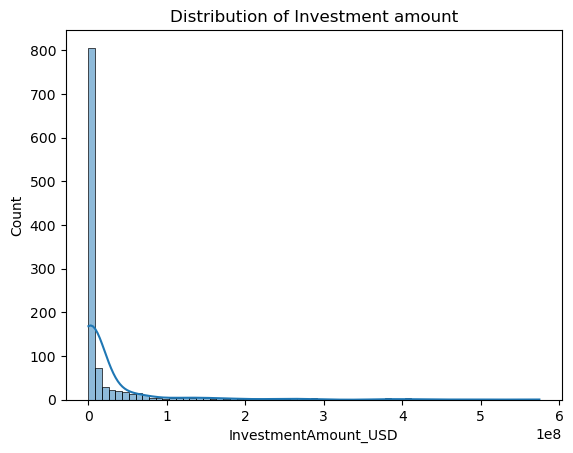

In [10]:
sns.histplot(df['InvestmentAmount_USD'],kde=True)
plt.title('Distribution of Investment amount')
plt.show()

In [11]:
df['InvestmentAmount_USD'].describe()

count    1.100000e+03
mean     2.553295e+07
std      7.266655e+07
min      5.000000e+03
25%      1.697500e+05
50%      1.114500e+06
75%      1.017250e+07
max      5.746760e+08
Name: InvestmentAmount_USD, dtype: float64

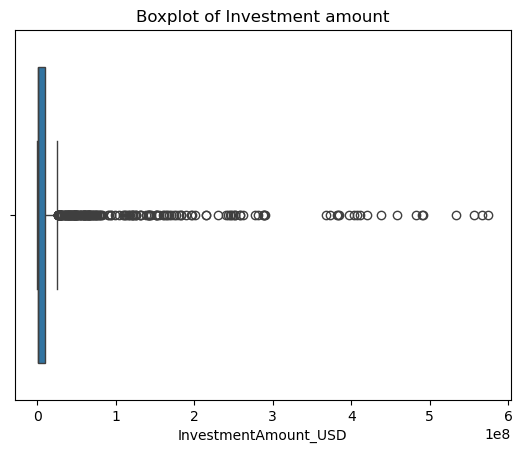

In [12]:
sns.boxplot(x=df['InvestmentAmount_USD'])
plt.title('Boxplot of Investment amount')
plt.show()


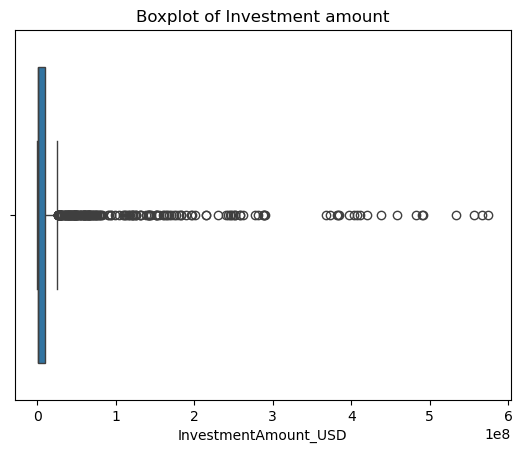

In [13]:
sns.boxplot(x=df['InvestmentAmount_USD'])
plt.title('Boxplot of Investment amount')
plt.show()

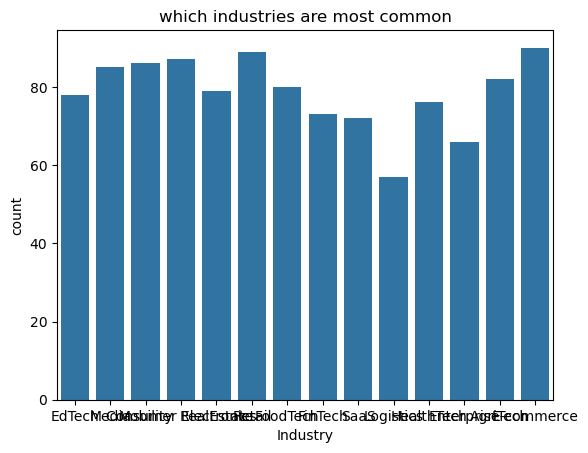

In [14]:
# Which industries are most common?

sns.countplot(x=df['Industry'])
plt.title('which industries are most common')
plt.show()

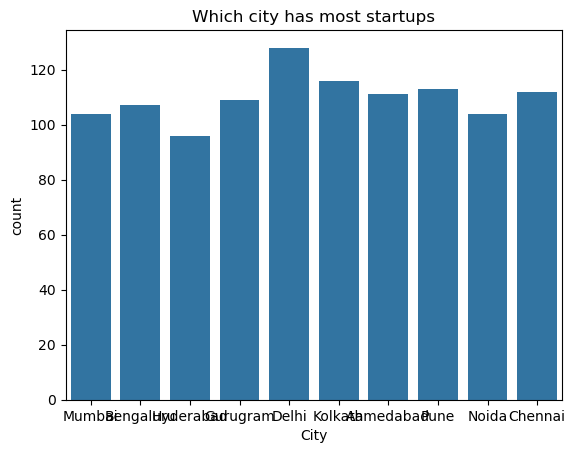

In [15]:
# Which cities have the most startups?

sns.countplot(x=df['City'])
plt.title('Which city has most startups')
plt.show()

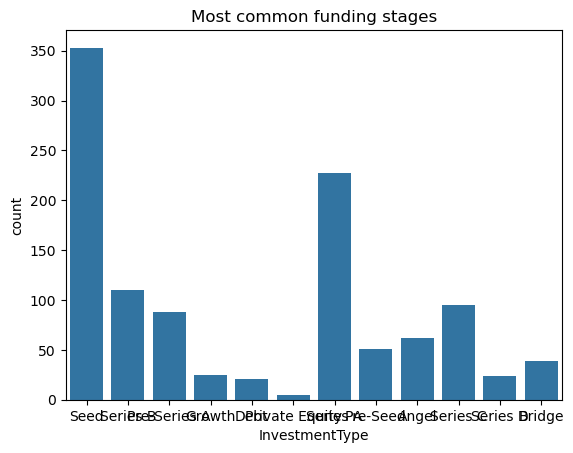

In [16]:
# Most common funding stage?

sns.countplot(x=df['InvestmentType'])
plt.title('Most common funding stages')
plt.show()

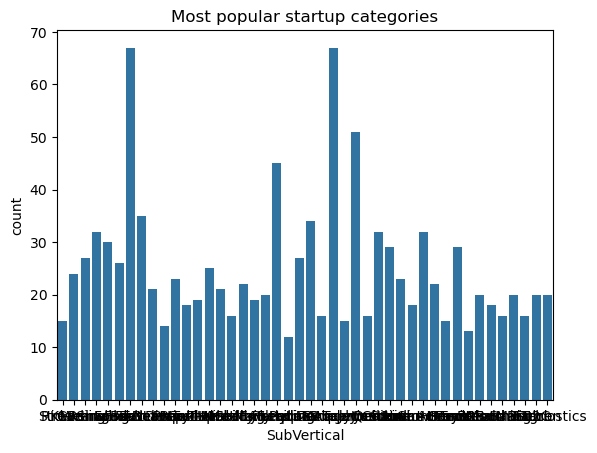

In [17]:
# Most popular startup categories?
sns.countplot(x=df['SubVertical'])
plt.title('Most popular startup categories')
plt.show()

**Bivariate analysis**

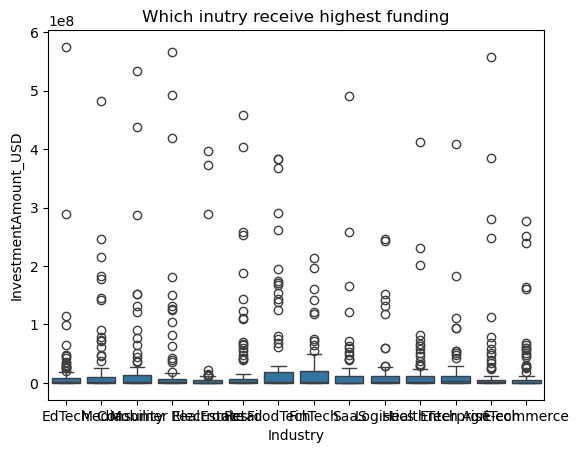

In [18]:
# Which industries receive highest funding?

sns.boxplot(x=df['Industry'],y=df['InvestmentAmount_USD'])
plt.title('Which inutry receive highest funding')
plt.show()

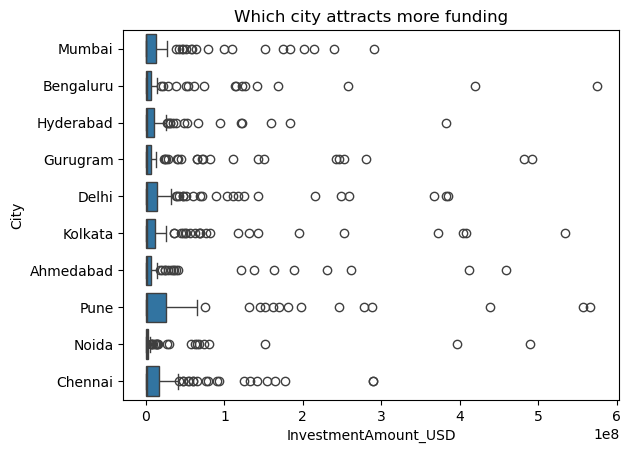

In [19]:
# Which cities attract more funding?

sns.boxplot(x=df['InvestmentAmount_USD'],y=df['City'])
plt.title('Which city attracts more funding')
plt.show()

In [20]:
# Which industries dominate which cities?

city_industry = pd.crosstab(df['City'], df['Industry'])

In [21]:
top_cities = df['City'].value_counts().head(10).index
top_industries = df['Industry'].value_counts().head(5).index

filtered = city_industry.loc[top_cities, top_industries]

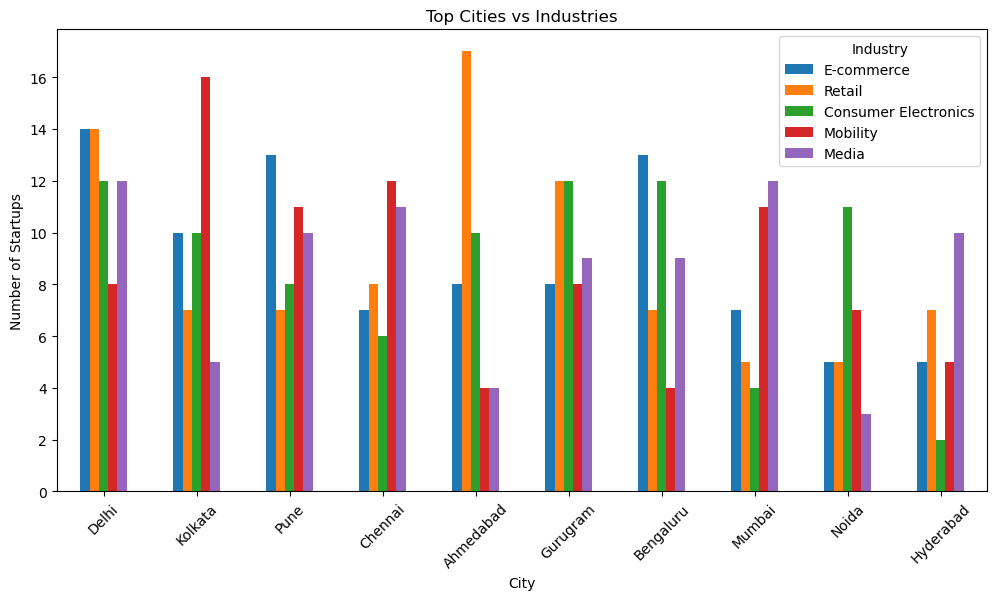

In [22]:

filtered.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top Cities vs Industries')
plt.xlabel('City')
plt.ylabel('Number of Startups')
plt.xticks(rotation=45)
plt.legend(title='Industry')
plt.show()

**Feature engineering**

In [23]:
# Converting date

df['Date']=pd.to_datetime(df['Date'])

C:\Users\Mayur\AppData\Local\Temp\ipykernel_15304\2561689917.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date']=pd.to_datetime(df['Date'])


In [24]:
# Extracting month and year from date column

df['year']=df['Date'].dt.year
df['month']=df['Date'].dt.month


In [25]:
df['Investor_Count'] = (
    df['Investors']
    .astype(str)
    .apply(lambda x: len(x.split(',')))
)

In [26]:
successful_stages = [
    'Series A',
    'Series B',
    'Series C',
    'Series D',
    'Growth',
    'Private Equity'
]

df['Success'] = df['InvestmentType'].isin(successful_stages).astype(int)

In [27]:
df[['InvestmentType','Success']].head(10)

,InvestmentType,Success
0,Seed,0
1,Seed,0
2,Series B,1
3,Seed,0
4,Seed,0
5,Pre-Series A,0
6,Seed,0
7,Growth,1
8,Seed,0
9,Series B,1


In [28]:
df['Success'].value_counts()

Success
0    614
1    486
Name: count, dtype: int64

In [29]:
# Removing the unwnted columns

df=df.drop(['Startup', 'Date', 'Investors', 'InvestmentType'],axis=1)

In [30]:
df.head()

,Industry,SubVertical,City,InvestmentAmount_USD,year,month,Investor_Count,Success
0,EdTech,K12,Mumbai,199000,2023,4,1,0
1,Media,Streaming,Bengaluru,1668000,2025,1,1,0
2,Mobility,Ride Sharing,Hyderabad,38052000,2021,3,2,1
3,Consumer Electronics,Wearables,Gurugram,455000,2023,9,2,0
4,RealEstate,Rental Tech,Mumbai,89000,2024,1,1,0


**Encoding - Train/Test Split - Model Training.**

In [31]:
df.columns


Index(['Industry', 'SubVertical', 'City', 'InvestmentAmount_USD', 'year',
       'month', 'Investor_Count', 'Success'],
      dtype='object')

In [32]:
df.dtypes

Industry                object
SubVertical             object
City                    object
InvestmentAmount_USD     int64
year                     int32
month                    int32
Investor_Count           int64
Success                  int64
dtype: object

In [33]:
le=LabelEncoder()

df['Industry'] = le.fit_transform(df['Industry'])
df['SubVertical'] = le.fit_transform(df['SubVertical'])
df['City'] = le.fit_transform(df['City'])

In [34]:
df.head()

,Industry,SubVertical,City,InvestmentAmount_USD,year,month,Investor_Count,Success
0,3,20,7,199000,2023,4,1,0
1,9,37,1,1668000,2025,1,1,0
2,10,32,5,38052000,2021,3,2,1
3,1,43,4,455000,2023,9,2,0
4,11,31,7,89000,2024,1,1,0


**Model training**

In [35]:
X = df.drop('Success', axis=1)
y = df['Success']

In [36]:
print(X.head())
print(y.head())

   Industry  SubVertical  City  InvestmentAmount_USD  year  month  \
0         3           20     7                199000  2023      4   
1         9           37     1               1668000  2025      1   
2        10           32     5              38052000  2021      3   
3         1           43     4                455000  2023      9   
4        11           31     7                 89000  2024      1   

   Investor_Count  
0               1  
1               1  
2               2  
3               2  
4               1  
0    0
1    0
2    1
3    0
4    0
Name: Success, dtype: int64


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
print(X_train.shape)
print(X_test.shape)

(880, 7)
(220, 7)


**Model training**


In [39]:
# 1. Logistic regression


lr=LogisticRegression()
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred_lr = lr.predict(X_test)

In [41]:

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.8863636363636364
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       126
           1       0.94      0.79      0.86        94

    accuracy                           0.89       220
   macro avg       0.90      0.87      0.88       220
weighted avg       0.89      0.89      0.88       220

[[121   5]
 [ 20  74]]


In [42]:
# Random forest

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier()
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred_rf = rf.predict(X_test)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9136363636363637
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       126
           1       0.87      0.94      0.90        94

    accuracy                           0.91       220
   macro avg       0.91      0.92      0.91       220
weighted avg       0.92      0.91      0.91       220

[[113  13]
 [  6  88]]


In [45]:
# Comparing the accuracies

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.8863636363636364
Random Forest: 0.9136363636363637


In [46]:

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.90      0.92       126
           1       0.87      0.94      0.90        94

    accuracy                           0.91       220
   macro avg       0.91      0.92      0.91       220
weighted avg       0.92      0.91      0.91       220



In [47]:


print(confusion_matrix(y_test, y_pred_rf))

[[113  13]
 [  6  88]]


In [48]:
# Which factors contribute most to startup success

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                Feature  Importance
3  InvestmentAmount_USD    0.799769
1           SubVertical    0.047338
5                 month    0.038507
2                  City    0.037216
0              Industry    0.032619
4                  year    0.025928
6        Investor_Count    0.018622


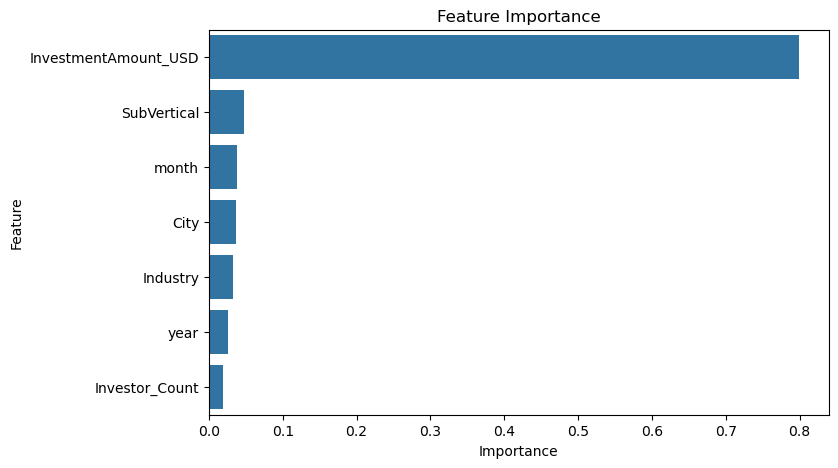

In [49]:

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance')
plt.show()

In [50]:
import pickle

pickle.dump(rf, open('startup_model.pkl', 'wb'))

In [52]:

le_industry = LabelEncoder()
le_subvertical = LabelEncoder()
le_city = LabelEncoder()

df['Industry'] = le_industry.fit_transform(df['Industry'])
df['SubVertical'] = le_subvertical.fit_transform(df['SubVertical'])
df['City'] = le_city.fit_transform(df['City'])

In [53]:

pickle.dump(le_industry, open('industry_encoder.pkl', 'wb'))
pickle.dump(le_subvertical, open('subvertical_encoder.pkl', 'wb'))
pickle.dump(le_city, open('city_encoder.pkl', 'wb'))

In [54]:
df.head()

,Industry,SubVertical,City,InvestmentAmount_USD,year,month,Investor_Count,Success
0,3,20,7,199000,2023,4,1,0
1,9,37,1,1668000,2025,1,1,0
2,10,32,5,38052000,2021,3,2,1
3,1,43,4,455000,2023,9,2,0
4,11,31,7,89000,2024,1,1,0


In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.90      0.92       126
           1       0.87      0.94      0.90        94

    accuracy                           0.91       220
   macro avg       0.91      0.92      0.91       220
weighted avg       0.92      0.91      0.91       220



In [64]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                Feature  Importance
3  InvestmentAmount_USD    0.799769
1           SubVertical    0.047338
5                 month    0.038507
2                  City    0.037216
0              Industry    0.032619
4                  year    0.025928
6        Investor_Count    0.018622


In [65]:
pip install steamlit

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement steamlit (from versions: none)
ERROR: No matching distribution found for steamlit


In [66]:
import streamlit as st
import pickle

In [67]:
model = pickle.load(open('startup_model.pkl', 'rb'))

st.title("Startup Success Prediction")

st.write("Enter startup details to predict success")

2026-06-22 16:57:41.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:41.828 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:41.846 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:41.888 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:41.903 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:41.912 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [68]:
industry = st.number_input("Industry", min_value=0)

subvertical = st.number_input("SubVertical", min_value=0)

city = st.number_input("City", min_value=0)

investment = st.number_input(
    "Investment Amount (USD)",
    min_value=0
)

year = st.number_input(
    "Year",
    min_value=2000,
    max_value=2030
)

month = st.number_input(
    "Month",
    min_value=1,
    max_value=12
)

investor_count = st.number_input(
    "Investor Count",
    min_value=1
)

2026-06-22 16:57:41.994 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:41.996 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.007 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.017 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.020 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.022 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.026 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [69]:
if st.button("Predict"):

    data = pd.DataFrame({
        'Industry':[industry],
        'SubVertical':[subvertical],
        'City':[city],
        'InvestmentAmount_USD':[investment],
        'year':[year],
        'month':[month],
        'Investor_Count':[investor_count]
    })

    prediction = model.predict(data)

    if prediction[0] == 1:
        st.success("Startup is likely to be Successful")
    else:
        st.error("Startup is likely to be Unsuccessful")

2026-06-22 16:57:42.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.203 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-22 16:57:42.209 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
